## Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", None)

In [2]:
RAW_PATH = "cleaned_stock_data.csv"   

raw = pd.read_csv(RAW_PATH, header=[0, 1], skiprows=[2])
raw.columns = [f"{a}_{b}" if b != "Ticker" else "Date" for a, b in raw.columns]
raw["Date"] = pd.to_datetime(raw["Date"])
raw = raw.sort_values("Date").reset_index(drop=True)

TICKERS = ["AAPL", "MSFT", "SPY"]
data = {}
for t in TICKERS:
    sub = raw[["Date"] + [f"{c}_{t}" for c in ["Open", "High", "Low", "Close", "Volume"]]].copy()
    sub.columns = ["Date", "Open", "High", "Low", "Close", "Volume"]
    data[t] = sub

print("Rows per ticker:", len(data["AAPL"]))
print("Date range:", raw["Date"].min().date(), "->", raw["Date"].max().date())
data["AAPL"].head()

Rows per ticker: 1254
Date range: 2021-06-30 -> 2026-06-29


,Date,Open,High,Low,Close,Volume
0,2021-06-30,132.73204,133.94073,132.43962,133.50210,63261400
1,2021-07-01,133.15110,133.86266,132.33229,133.80417,52485800
2,2021-07-02,134.41827,136.46526,134.27206,136.42627,78852600
3,2021-07-06,136.53352,139.53574,136.53352,138.43428,108181800
4,2021-07-07,139.91586,141.23180,139.05809,140.91988,104911600


In [3]:
TICKER = "AAPL"
df = data[TICKER].copy()
print("Missing values check (should be 0 - data is already cleaned):")
print(df.isnull().sum())

Missing values check (should be 0 - data is already cleaned):
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


## Interactive Candlestick Chart (Plotly)
Shows Open/High/Low/Close per day. Green candle = day closed higher than it opened; red = closed lower.
The range slider beneath the chart lets you zoom into any period.

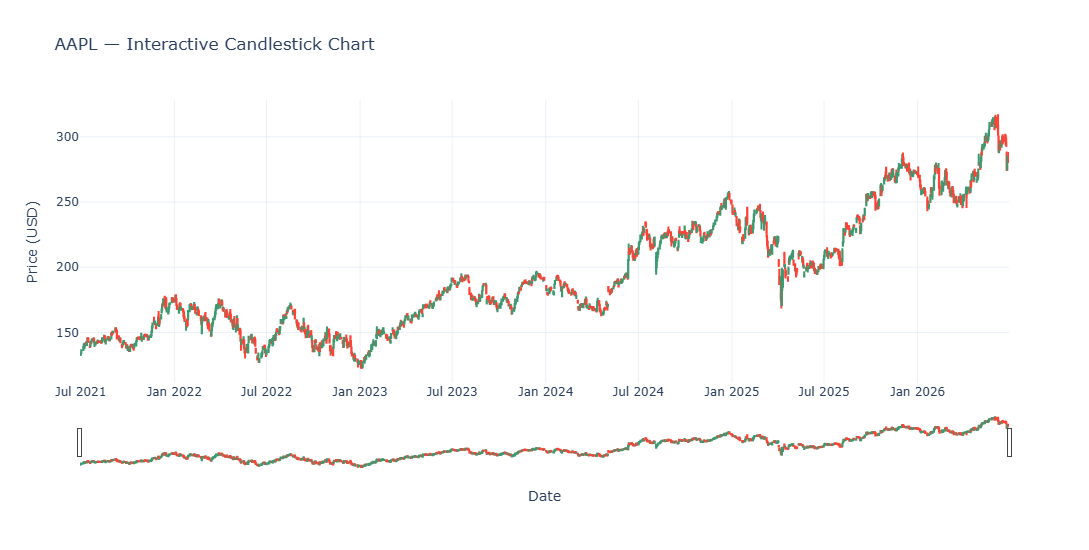

In [4]:
fig = go.Figure(data=[go.Candlestick(
    x=df["Date"], open=df["Open"], high=df["High"],
    low=df["Low"], close=df["Close"], name=TICKER
)])
fig.update_layout(
    title=f"{TICKER} — Interactive Candlestick Chart",
    xaxis_title="Date", yaxis_title="Price (USD)",
    xaxis_rangeslider_visible=True, template="plotly_white", height=550
)
fig.show()

## SMA / EMA (50 & 200-day) and Crossovers
- **SMA** (Simple Moving Average): flat/equal weight over the window — smoother, slower to react.
- **EMA** (Exponential Moving Average): weights recent prices more — reacts faster to new information.
- **Golden Cross**: SMA50 crosses *above* SMA200 → often read as a bullish signal.
- **Death Cross**: SMA50 crosses *below* SMA200 → often read as a bearish signal.

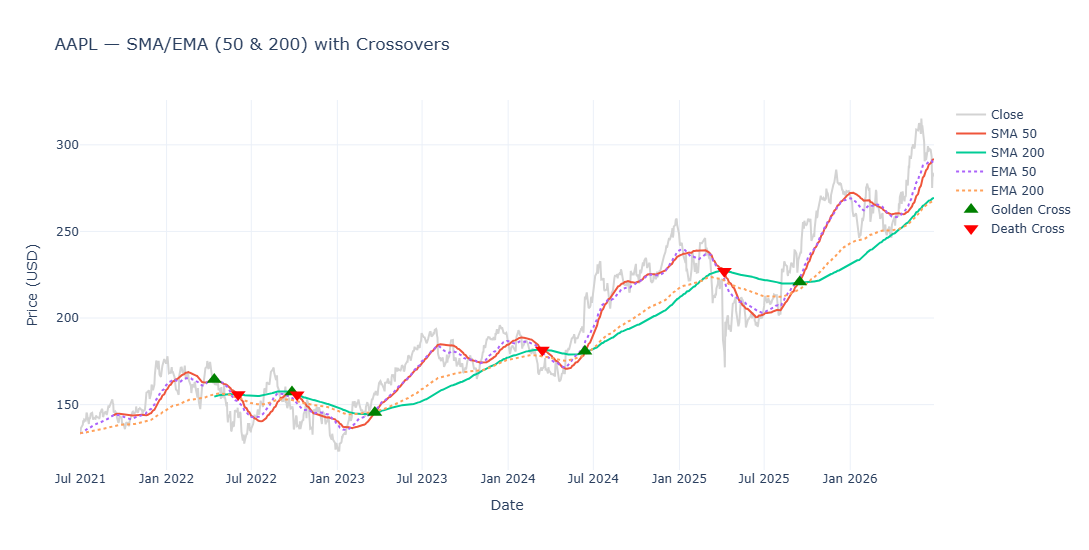

Golden crosses (5):
[datetime.date(2022, 4, 13), datetime.date(2022, 9, 26), datetime.date(2023, 3, 22), datetime.date(2024, 6, 13), datetime.date(2025, 9, 15)]

Death crosses (4):
[datetime.date(2022, 6, 3), datetime.date(2022, 10, 7), datetime.date(2024, 3, 14), datetime.date(2025, 4, 7)]


In [5]:
df["SMA50"]  = df["Close"].rolling(50).mean()
df["SMA200"] = df["Close"].rolling(200).mean()
df["EMA50"]  = df["Close"].ewm(span=50, adjust=False).mean()
df["EMA200"] = df["Close"].ewm(span=200, adjust=False).mean()

# Detect crossover points
df["signal"] = 0
df.loc[df["SMA50"] > df["SMA200"], "signal"] = 1
df["cross"] = df["signal"].diff()
golden = df[df["cross"] == 1]   
death  = df[df["cross"] == -1]  

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["Date"], y=df["Close"], name="Close", line=dict(color="lightgrey")))
fig.add_trace(go.Scatter(x=df["Date"], y=df["SMA50"], name="SMA 50"))
fig.add_trace(go.Scatter(x=df["Date"], y=df["SMA200"], name="SMA 200"))
fig.add_trace(go.Scatter(x=df["Date"], y=df["EMA50"], name="EMA 50", line=dict(dash="dot")))
fig.add_trace(go.Scatter(x=df["Date"], y=df["EMA200"], name="EMA 200", line=dict(dash="dot")))
fig.add_trace(go.Scatter(x=golden["Date"], y=golden["SMA50"], mode="markers",
              marker=dict(symbol="triangle-up", size=13, color="green"), name="Golden Cross"))
fig.add_trace(go.Scatter(x=death["Date"], y=death["SMA50"], mode="markers",
              marker=dict(symbol="triangle-down", size=13, color="red"), name="Death Cross"))
fig.update_layout(title=f"{TICKER} — SMA/EMA (50 & 200) with Crossovers",
                   xaxis_title="Date", yaxis_title="Price (USD)",
                   template="plotly_white", height=550)
fig.show()

print(f"Golden crosses ({len(golden)}):"); print(golden["Date"].dt.date.tolist())
print(f"\nDeath crosses ({len(death)}):"); print(death["Date"].dt.date.tolist())

## Bollinger Bands & Volatility Clustering
Bollinger Bands = 20-day MA ± 2 standard deviations. Bands widen in volatile periods and
tighten in calm periods — this "band width" is a direct visual proxy for volatility clustering
(the well-known fact that large price moves tend to be followed by more large moves,
and calm periods by more calm periods).

We also verify clustering statistically: the autocorrelation of *absolute* daily returns should be
positive at short lags if volatility clusters.

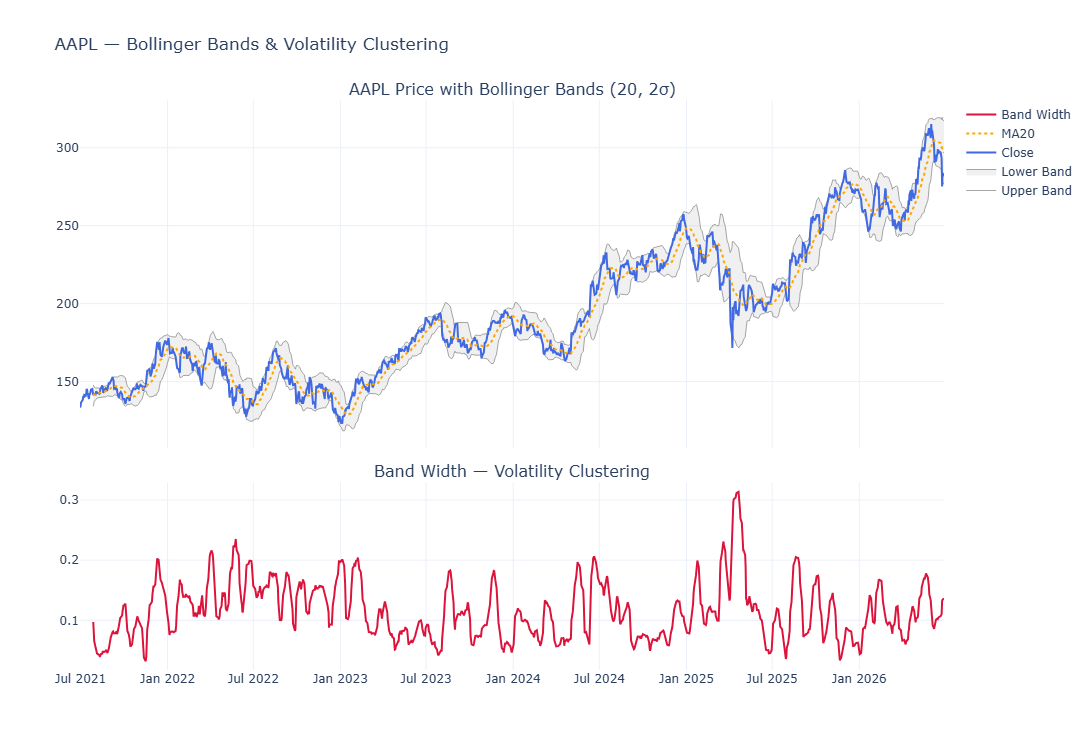

In [6]:
WINDOW = 20
df["MA20"]  = df["Close"].rolling(WINDOW).mean()
df["STD20"] = df["Close"].rolling(WINDOW).std()
df["Upper"] = df["MA20"] + 2 * df["STD20"]
df["Lower"] = df["MA20"] - 2 * df["STD20"]
df["BandWidth"] = (df["Upper"] - df["Lower"]) / df["MA20"]

df["Return"] = df["Close"].pct_change()
df["RollVol20"] = df["Return"].rolling(20).std() * np.sqrt(252)   

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.65, 0.35],
                     vertical_spacing=0.06,
                     subplot_titles=(f"{TICKER} Price with Bollinger Bands (20, 2σ)",
                                      "Band Width — Volatility Clustering"))
fig.add_trace(go.Scatter(x=df["Date"], y=df["Upper"], line=dict(width=0.7, color="grey"), name="Upper Band"), row=1, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=df["Lower"], line=dict(width=0.7, color="grey"), name="Lower Band",
                          fill="tonexty", fillcolor="rgba(180,180,180,0.2)"), row=1, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=df["Close"], line=dict(color="royalblue"), name="Close"), row=1, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=df["MA20"], line=dict(color="orange", dash="dot"), name="MA20"), row=1, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=df["BandWidth"], line=dict(color="crimson"), name="Band Width"), row=2, col=1)
fig.update_layout(template="plotly_white", height=750, title=f"{TICKER} — Bollinger Bands & Volatility Clustering")
fig.show()

In [7]:
from statsmodels.tsa.stattools import acf

ac = acf(df["Return"].dropna().abs(), nlags=10)
print("Autocorrelation of |daily returns| at lags 1-10 (positive values = volatility clustering):")
for lag, val in enumerate(ac[1:], start=1):
    print(f"  lag {lag:2d}: {val:.3f}")

Autocorrelation of |daily returns| at lags 1-10 (positive values = volatility clustering):
  lag  1: 0.203
  lag  2: 0.091
  lag  3: 0.122
  lag  4: 0.134
  lag  5: 0.137
  lag  6: 0.090
  lag  7: 0.064
  lag  8: 0.102
  lag  9: 0.127
  lag 10: 0.090


## Monthly Seasonality & Day-of-Week Returns
Average daily return grouped by calendar month and by weekday. Small sample caveat: 5 years of
data means each month only has ~5 observations of "that month", so treat any pattern as
suggestive, not statistically strong evidence, unless a formal significance test is added.

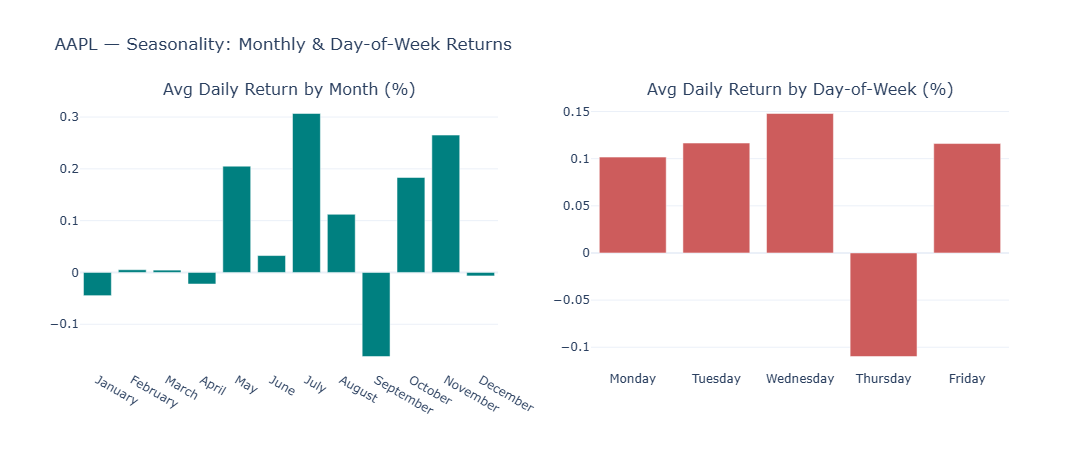

Monthly average return (%):
Month
January     -0.045
February     0.005
March        0.005
April       -0.022
May          0.205
June         0.033
July         0.307
August       0.112
September   -0.162
October      0.183
November     0.265
December    -0.007
Name: Return, dtype: float64

Day-of-week average return (%):
DOW
Monday       0.102
Tuesday      0.117
Wednesday    0.148
Thursday    -0.110
Friday       0.116
Name: Return, dtype: float64


In [8]:
df["Month"] = df["Date"].dt.month_name()
df["DOW"]   = df["Date"].dt.day_name()

month_order = ["January","February","March","April","May","June","July","August",
               "September","October","November","December"]
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday"]

monthly = df.groupby("Month")["Return"].mean().reindex(month_order) * 100
dow     = df.groupby("DOW")["Return"].mean().reindex(dow_order) * 100

fig = make_subplots(rows=1, cols=2, subplot_titles=("Avg Daily Return by Month (%)",
                                                     "Avg Daily Return by Day-of-Week (%)"))
fig.add_trace(go.Bar(x=monthly.index, y=monthly.values, marker_color="teal", name="Monthly"), row=1, col=1)
fig.add_trace(go.Bar(x=dow.index, y=dow.values, marker_color="indianred", name="Day-of-Week"), row=1, col=2)
fig.update_layout(template="plotly_white", height=450,
                   title=f"{TICKER} — Seasonality: Monthly & Day-of-Week Returns", showlegend=False)
fig.show()

print("Monthly average return (%):"); print(monthly.round(3))
print("\nDay-of-week average return (%):"); print(dow.round(3))

## Augmented Dickey-Fuller (ADF) Stationarity Test
ARIMA/SARIMA require a stationary series. We test:
1. The **raw Close price** (expected: non-stationary — prices trend/wander, this is normal for stock levels)
2. The **log returns** (expected: stationary — this tells us the differencing order `d` to use, usually `d=1`)

**Null hypothesis (H0):** the series has a unit root (is non-stationary).
If p-value < 0.05 → reject H0 → series is stationary.

In [9]:
from statsmodels.tsa.stattools import adfuller

df["LogClose"]  = np.log(df["Close"])
df["LogReturn"] = df["LogClose"].diff()

def run_adf(series, label):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"Verdict: {verdict}\n")

run_adf(df["Close"], "Close Price (level)")
run_adf(df["LogReturn"], "Log Returns (1st difference)")

--- ADF Test: Close Price (level) ---
ADF Statistic : -0.9099
p-value       : 0.7847
Critical Value (1%): -3.4356
Critical Value (5%): -2.8638
Critical Value (10%): -2.5680
Verdict: NON-STATIONARY

--- ADF Test: Log Returns (1st difference) ---
ADF Statistic : -34.7665
p-value       : 0.0000
Critical Value (1%): -3.4356
Critical Value (5%): -2.8639
Critical Value (10%): -2.5680
Verdict: STATIONARY



## Chronological Train/Test Split
Time series must **never** be shuffled or split randomly — that would leak future information
into training. We hold out the **last 30 trading days** as the test set and train on everything
before that.

In [10]:
FORECAST_HORIZON = 30  
df_sorted = df.sort_values("Date").reset_index(drop=True)

train = df_sorted.iloc[:-FORECAST_HORIZON].copy()
test  = df_sorted.iloc[-FORECAST_HORIZON:].copy()

print(f"Total rows : {len(df_sorted)}")
print(f"Train      : {len(train)}  ({train['Date'].min().date()} -> {train['Date'].max().date()})")
print(f"Test       : {len(test)}  ({test['Date'].min().date()} -> {test['Date'].max().date()})")

Total rows : 1254
Train      : 1224  (2021-06-30 -> 2026-05-14)
Test       : 30  (2026-05-15 -> 2026-06-29)


## SARIMA Model & 30-Day Forecast
Since the ADF test showed the price series needs 1 differencing to become stationary, we fix
`d=1` and search a small grid of `(p, q)` combinations, picking the model with the lowest AIC
(a standard, principled way to choose ARIMA order without needing `pmdarima`).

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_aic, best_order, best_model = np.inf, None, None
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = SARIMAX(train["Close"], order=(p, 1, q),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if m.aic < best_aic:
                best_aic, best_order, best_model = m.aic, (p, 1, q), m
        except Exception:
            continue

print(f"Best order by AIC: ARIMA{best_order}   AIC={best_aic:.2f}")

HORIZON = len(test)
fc = best_model.get_forecast(steps=HORIZON)
pred_mean = fc.predicted_mean
conf_int = fc.conf_int(alpha=0.05)

sarima_forecast = pd.DataFrame({
    "Date": test["Date"].values,
    "Forecast": pred_mean.values,
    "Lower": conf_int.iloc[:, 0].values,
    "Upper": conf_int.iloc[:, 1].values,
    "Actual": test["Close"].values
})
sarima_forecast.head()

C:\Users\shaya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order by AIC: ARIMA(0, 1, 2)   AIC=6334.69


,Date,Forecast,Lower,Upper,Actual
0,2026-05-15,298.234981,291.889704,304.580259,300.23
1,2026-05-18,298.221903,289.058869,307.384936,297.84
2,2026-05-19,298.221903,286.866393,309.577412,298.97
3,2026-05-20,298.221903,285.033499,311.410306,302.25
4,2026-05-21,298.221903,283.425944,313.017861,304.99


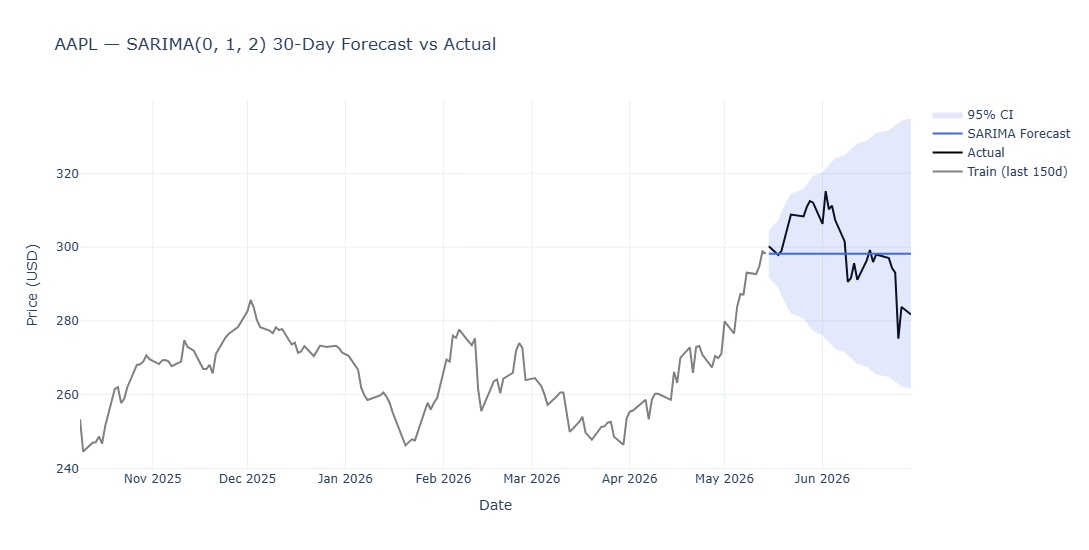

In [12]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=train["Date"].tail(150), y=train["Close"].tail(150),
                          name="Train (last 150d)", line=dict(color="grey")))
fig.add_trace(go.Scatter(x=sarima_forecast["Date"], y=sarima_forecast["Actual"],
                          name="Actual", line=dict(color="black")))
fig.add_trace(go.Scatter(x=sarima_forecast["Date"], y=sarima_forecast["Forecast"],
                          name="SARIMA Forecast", line=dict(color="royalblue")))
fig.add_trace(go.Scatter(x=sarima_forecast["Date"], y=sarima_forecast["Upper"],
                          line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=sarima_forecast["Date"], y=sarima_forecast["Lower"], line=dict(width=0),
                          fill="tonexty", fillcolor="rgba(65,105,225,0.15)", name="95% CI"))
fig.update_layout(title=f"{TICKER} — SARIMA{best_order} 30-Day Forecast vs Actual",
                   xaxis_title="Date", yaxis_title="Price (USD)", template="plotly_white", height=550)
fig.show()

## Facebook Prophet Model (with Holidays)
Prophet decomposes the series into trend + seasonality + holiday effects. We add **US
holidays** via `add_country_holidays`, which lets the model account for market closures
and the surrounding effect on price behavior. Forecast frequency is set to **business days**
(`freq="B"`) to match the stock market's actual trading calendar.

In [13]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)
from prophet import Prophet

prop_df = train[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})

m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m.add_country_holidays(country_name="US")
m.fit(prop_df)

future = m.make_future_dataframe(periods=HORIZON, freq="B")
fcst = m.predict(future)

prophet_forecast = fcst[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(HORIZON).reset_index(drop=True)
prophet_forecast["Actual"] = test["Close"].values
prophet_forecast.head()

14:31:44 - cmdstanpy - INFO - Chain [1] start processing
14:31:45 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,Actual
0,2026-05-15,276.553880,266.062735,287.411253,300.23
1,2026-05-18,276.879881,266.061606,288.119880,297.84
2,2026-05-19,276.728254,265.551820,287.907599,298.97
3,2026-05-20,276.834100,265.432483,288.289636,302.25
4,2026-05-21,276.569522,265.677643,287.648023,304.99


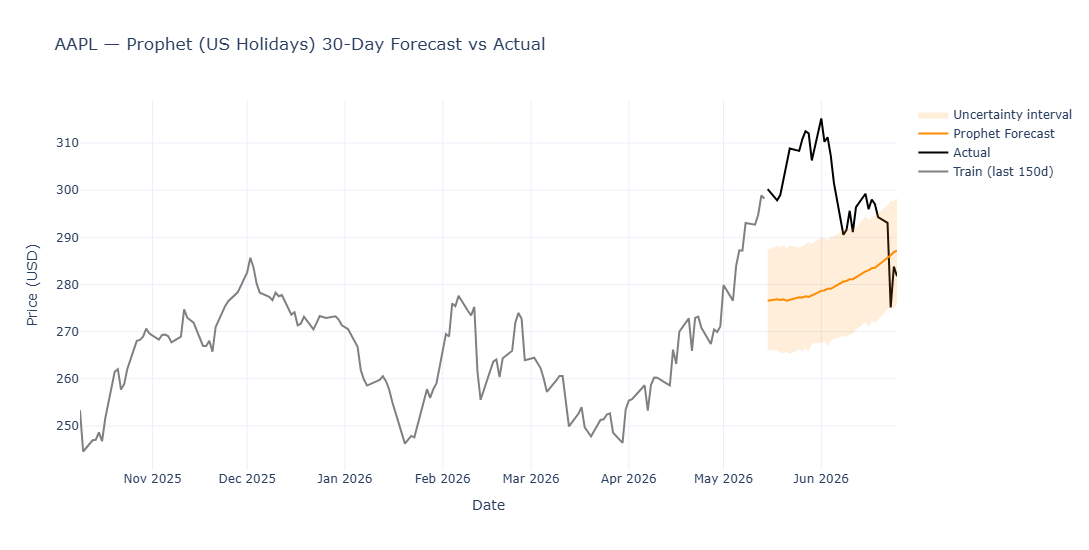

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=train["Date"].tail(150), y=train["Close"].tail(150),
                          name="Train (last 150d)", line=dict(color="grey")))
fig.add_trace(go.Scatter(x=prophet_forecast["ds"], y=prophet_forecast["Actual"],
                          name="Actual", line=dict(color="black")))
fig.add_trace(go.Scatter(x=prophet_forecast["ds"], y=prophet_forecast["yhat"],
                          name="Prophet Forecast", line=dict(color="darkorange")))
fig.add_trace(go.Scatter(x=prophet_forecast["ds"], y=prophet_forecast["yhat_upper"],
                          line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=prophet_forecast["ds"], y=prophet_forecast["yhat_lower"], line=dict(width=0),
                          fill="tonexty", fillcolor="rgba(255,140,0,0.15)", name="Uncertainty interval"))
fig.update_layout(title=f"{TICKER} — Prophet (US Holidays) 30-Day Forecast vs Actual",
                   xaxis_title="Date", yaxis_title="Price (USD)", template="plotly_white", height=550)
fig.show()

## Model Evaluation (RMSE & MAPE)
- **RMSE** (Root Mean Squared Error): average forecast error in the same units as price (USD) — penalizes large errors more.
- **MAPE** (Mean Absolute Percentage Error): average error as a % of actual price — easier to compare across stocks/scales.
Lower is better for both.

In [15]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = pd.DataFrame({
    "Model": ["SARIMA", "Prophet"],
    "RMSE": [rmse(sarima_forecast["Actual"], sarima_forecast["Forecast"]),
             rmse(prophet_forecast["Actual"], prophet_forecast["yhat"])],
    "MAPE (%)": [mape(sarima_forecast["Actual"], sarima_forecast["Forecast"]),
                 mape(prophet_forecast["Actual"], prophet_forecast["yhat"])]
})
results

,Model,RMSE,MAPE (%)
0,SARIMA,9.701497,2.578832
1,Prophet,23.003250,6.815292
